In [9]:

from utils import (
    read_intensities, 
    read_kmer_positions,
    get_sequence_from_fasta,
    get_kmer_variants,
    match_kmers_to_wildcards,
    select_random_probes,
    project_kmers_to_random_probes,
    run_aff_rand_regression_scan,build_allele_matrix, run_regression,
    get_all_kmer_wildcards
)

genome =  "../../../../../d/OneDrive - McGill University/repos/hg38_ucsc.fa"
intensities = read_intensities("./data/ENCFF003ZRP_ENCFF274YGF.ChIPBM.tf.txt")
kmers = read_kmer_positions("./data/ENCFF274YGF_K562_DNase-seq_Crawford_GRCh38.ChIPBM.array.txt")
dhs = 1
region = "chr6:41071098-41071113"
kmer_size = 8
num_random = 1000
mode="neg-binomial"

In [3]:
used_regions = set(kmers.keys())

chrom, coords = region.split(":")
start, end = map(int, coords.split("-"))
region_seq = get_sequence_from_fasta(chrom, start, end, genome)
region_seq 

'AGGGCAAACCAGGTAA'

In [ ]:
num_random = 2
mode="neg-binomial"
import csv
import math

def get_all_kmer_wildcards(kmer_seq):
    """
    Given a k-mer sequence, return:
    - {snp_index: wildcarded_kmer} for all positions
    """
    wildcard_variants = {}
    for i in range(len(kmer_seq)):
        wildcard = list(kmer_seq)
        wildcard[i] = "."
        wildcard_kmer = ''.join(wildcard)
        wildcard_variants[i] = wildcard_kmer
    return wildcard_variants

rows = []

for i in range(len(region_seq) - kmer_size + 1):
    kmer_seq = region_seq[i:i + kmer_size]
    motif_start = start + i  # genomic position of start of k-mer

    # Original logic for actual regression
    kmer_list, original_wildcards, snp_indices = get_kmer_variants(kmer_seq, kmer_size)
    comp_alleles, matched = match_kmers_to_wildcards(kmers, original_wildcards, snp_indices, kmer_seq)

    rand_seed = hash((region, motif_start)) % (2**32)
    rand_probes = select_random_probes(kmers, used_regions, num_random=num_random, seed=rand_seed)
    split_random = project_kmers_to_random_probes(rand_probes, original_wildcards, kmer_list, kmers)

    for motif_pos in comp_alleles:
        for snp_index in comp_alleles[motif_pos]:
            ref_allele = comp_alleles[motif_pos][snp_index]
            
            try:
                matched_block = {motif_pos: {snp_index: matched[motif_pos]}}
                random_block  = {motif_pos: {snp_index: split_random[motif_pos]}}
                comp_block    = {motif_pos: {snp_index: ref_allele}}

                aff_stats, rand_stats = run_aff_rand_regression_scan(
                    matched_block, 
                    random_block, 
                    intensities, 
                    dhs = dhs,
                    mode = mode
                )

            except KeyError:
                # Handle empty random case by assigning empty stats
                rand_stats = {}

                print(
                    f"[Warning] No matching random probes found for window {i}. "
                    f"Introducing NaN values in RAND. "
                    f"Consider increasing `num_random` above {num_random} to reduce missing data."
                )



            # Get all wildcarded versions of the current k-mer
            wildcard_variants = get_all_kmer_wildcards(kmer_seq)

            for snp_i, wildcard in wildcard_variants.items():
                for base in "ACGT":
                    filled = list(wildcard)
                    filled[snp_i] = base
                    filled_kmer = ''.join(filled)

                    # AFF
                    if base in aff_stats:
                        coef, _, pval = aff_stats[base]
                    else:
                        coef, pval = math.nan, math.nan
                    rows.append([wildcard, filled_kmer, i, snp_i, "AFF", coef, pval])

                    # RAND
                    if base in rand_stats:
                        coef, _, pval = rand_stats[base]
                    else:
                        coef, pval = math.nan, math.nan
                    rows.append([wildcard, filled_kmer, i, snp_i, "RAND", coef, pval])

# Save to CSV
with open("scan_output.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["wildcard_kmer", "filled_kmer", "window_index", "snp_index", "type", "coef", "pval"])
    writer.writerows(rows)


In [10]:
def regression_driver(
    probe_dict, 
    probe_intensities, 
    exclude_ref_allele=False,
    comp_alleles=None, 
    dhs=False, 
    mode="neg-binomial"
):
    """
    Generalized regression function for either AFF or RAND.

    Args:
        probe_dict (dict): matched or random dictionary
        probe_intensities (dict): Region -> intensity
        exclude_ref_allele (bool): If True, exclude the reference allele
        comp_alleles (dict or None): Required if exclude_ref_allele is True
        dhs (bool): Whether to include size covariate
        mode (str): Regression mode

    Returns:
        dict: Regression stats per allele
    """
    def extract_covariates(regions, region_to_kmer_pos):
        lp = []
        sl = []
        for region in regions:
            chrom, coords = region.split(":")
            start, end = map(int, coords.split("-"))
            size = end - start
            kmer_pos = region_to_kmer_pos.get(region, 0)
            lp_val = kmer_pos / size if size > 0 else 0.5
            lp.append(lp_val)
            sl.append(size)
        return lp, sl

    motif_pos = list(probe_dict.keys())[0]
    snp_index = list(probe_dict[motif_pos].keys())[0]

    exclude = set()
    if exclude_ref_allele:
        if comp_alleles is None:
            raise ValueError("comp_alleles must be provided when excluding ref allele")
        ref_allele = comp_alleles[motif_pos][snp_index]
        exclude = {ref_allele}

    matrix, values, used = build_allele_matrix(
        probe_dict, probe_intensities, exclude_alleles=exclude
    )

    kmer_pos = {
        r: probe_dict[motif_pos][snp_index][allele][r]
        for allele in probe_dict[motif_pos][snp_index]
        for r in probe_dict[motif_pos][snp_index][allele]
    }

    lp, sl = extract_covariates(used, kmer_pos)
    covars = {"lp": lp}
    if dhs:
        covars["sl"] = sl

    stats = run_regression(matrix, values, mode=mode, extra_covariates=covars)
    return stats


In [ ]:
import csv
import math

num_random = 500
mode = "neg-binomial"

def get_all_kmer_wildcards(kmer_seq):
    """
    Given a k-mer sequence, return:
    - {snp_index: wildcarded_kmer} for all positions
    """
    wildcard_variants = {}
    for i in range(len(kmer_seq)):
        wildcard = list(kmer_seq)
        wildcard[i] = "."
        wildcard_kmer = ''.join(wildcard)
        wildcard_variants[i] = wildcard_kmer
    return wildcard_variants

rows = []

for i in range(len(region_seq) - kmer_size + 1):
    kmer_seq = region_seq[i:i + kmer_size]
    motif_start = start + i

    kmer_list, original_wildcards, snp_indices = get_kmer_variants(kmer_seq, kmer_size)
    comp_alleles, matched = match_kmers_to_wildcards(kmers, original_wildcards, snp_indices, kmer_seq)

    rand_seed = hash((region, motif_start)) % (2**32)
    rand_probes = select_random_probes(kmers, used_regions, num_random=num_random, seed=rand_seed)
    split_random = project_kmers_to_random_probes(rand_probes, original_wildcards, kmer_list, kmers)

    for motif_pos in comp_alleles:
        for snp_index in comp_alleles[motif_pos]:
            ref_allele = comp_alleles[motif_pos][snp_index]

            matched_block = {motif_pos: {snp_index: matched[motif_pos]}}
            comp_block    = {motif_pos: {snp_index: ref_allele}}

            # Always run AFF
            aff_stats = regression_driver(
                matched_block,
                probe_intensities=intensities,
                exclude_ref_allele=False,
                dhs=dhs,
                mode=mode
            )

            # Try RAND, gracefully handle failure
            try:
                random_block = {motif_pos: {snp_index: split_random[motif_pos]}}
                rand_stats = regression_driver(
                    random_block,
                    probe_intensities=intensities,
                    exclude_ref_allele=False,
                    dhs=dhs,
                    mode=mode
                )
            except KeyError:
                rand_stats = {}
                print(
                    f"[Warning] No matching random probes found for window {i}. "
                    f"Introducing NaN values in RAND. "
                    f"Consider increasing `num_random` above {num_random} to reduce missing data."
                )

            # Wildcard and fill variants
            wildcard_variants = get_all_kmer_wildcards(kmer_seq)
            for snp_i, wildcard in wildcard_variants.items():
                for base in "ACGT":
                    filled = list(wildcard)
                    filled[snp_i] = base
                    filled_kmer = ''.join(filled)

                    # AFF
                    if base in aff_stats:
                        coef, _, pval = aff_stats[base]
                    else:
                        coef, pval = math.nan, math.nan
                    rows.append([wildcard, filled_kmer, i, snp_i, "AFF", base, coef, pval])

                    # RAND
                    if base in rand_stats:
                        coef, _, pval = rand_stats[base]
                    else:
                        coef, pval = math.nan, math.nan
                    rows.append([wildcard, filled_kmer, i, snp_i, "RAND", base, coef, pval])

# Save to CSV
with open("scan_output.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["wildcard_kmer", "filled_kmer", "window_index", "snp_index", "type", "coef", "pval"])
    writer.writerows(rows)


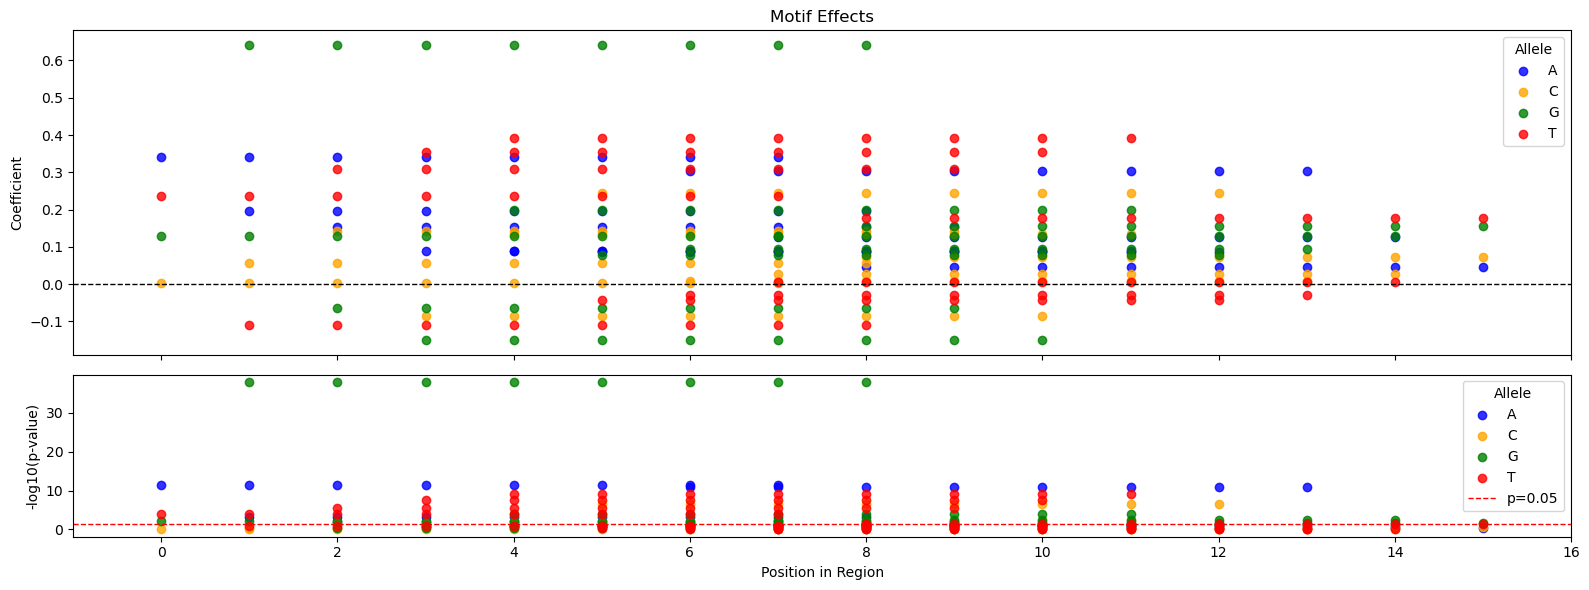

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

def plot_motif_effects(rows, region_length):
    # Convert to DataFrame
    df = pd.DataFrame(rows, columns=[
        "wildcard_kmer", "filled_kmer", "window_index", "snp_index", "type", "allele", "coef", "pval"
    ])

    # Keep only AFF rows
    df = df[df["type"] == "AFF"].copy()

    # Compute absolute position in region
    df["absolute_position"] = df["window_index"] + df["snp_index"]

    # Drop NaN values to avoid plotting artifacts
    df = df.dropna(subset=["coef", "pval", "allele"])
    
    # Initialize figure with two subplots
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(16, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
    )

    # Define allele colors
    color_map = {"A": "blue", "C": "orange", "G": "green", "T": "red"}

    # Plot coefficients
    for base in "ACGT":
        sub = df[df["allele"] == base]
        ax1.scatter(sub["absolute_position"], sub["coef"],
                    color=color_map[base], label=base, alpha=0.8)
    ax1.axhline(0, linestyle="--", color="black", linewidth=1)
    ax1.set_ylabel("Coefficient")
    ax1.legend(title="Allele")
    ax1.set_title("Motif Effects")

    # Plot -log10(p-value)
    for base in "ACGT":
        sub = df[df["allele"] == base]
        neglogp = -np.log10(sub["pval"].astype(float).replace(0, np.nextafter(0, 1)))
        ax2.scatter(sub["absolute_position"], neglogp,
                    color=color_map[base], label=base, alpha=0.8)

    ax2.axhline(-np.log10(0.05), linestyle="--", color="red", linewidth=1, label="p=0.05")
    ax2.set_ylabel("-log10(p-value)")
    ax2.set_xlabel("Position in Region")
    ax2.legend(title="Allele")

    ax1.set_xlim(-1, region_length)
    ax2.set_xlim(-1, region_length)

    plt.tight_layout()
    plt.show()


plot_motif_effects(rows, region_length=16)

In [39]:
genome =  "../../../../../d/OneDrive - McGill University/repos/hg38_ucsc.fa"
intensities = read_intensities("./data/ENCFF441PRL_ENCFF274YGF.ChIPBM.tf.txt")
kmers = read_kmer_positions("./data/ENCFF274YGF_K562_DNase-seq_Crawford_GRCh38.ChIPBM.array.txt")
dhs = 1
region = "chr5:1295200-1295300"
kmer_size = 8
num_random = 1000
mode="neg-binomial"

used_regions = set(kmers.keys())

chrom, coords = region.split(":")
start, end = map(int, coords.split("-"))
region_seq = get_sequence_from_fasta(chrom, start, end, genome)


def get_all_kmer_wildcards(kmer_seq):
    """
    Given a k-mer sequence, return:
    - {snp_index: wildcarded_kmer} for all positions
    """
    wildcard_variants = {}
    for i in range(len(kmer_seq)):
        wildcard = list(kmer_seq)
        wildcard[i] = "."
        wildcard_kmer = ''.join(wildcard)
        wildcard_variants[i] = wildcard_kmer
    return wildcard_variants

rows = []

for i in range(len(region_seq) - kmer_size + 1):
    kmer_seq = region_seq[i:i + kmer_size]
    motif_start = start + i

    kmer_list, original_wildcards, snp_indices = get_kmer_variants(kmer_seq, kmer_size)
    comp_alleles, matched = match_kmers_to_wildcards(kmers, original_wildcards, snp_indices, kmer_seq)

    rand_seed = hash((region, motif_start)) % (2**32)
    rand_probes = select_random_probes(kmers, used_regions, num_random=num_random, seed=rand_seed)
    split_random = project_kmers_to_random_probes(rand_probes, original_wildcards, kmer_list, kmers)

    for motif_pos in comp_alleles:
        for snp_index in comp_alleles[motif_pos]:
            ref_allele = comp_alleles[motif_pos][snp_index]

            matched_block = {motif_pos: {snp_index: matched[motif_pos]}}
            comp_block    = {motif_pos: {snp_index: ref_allele}}

            # Always run AFF
            aff_stats = regression_driver(
                matched_block,
                probe_intensities=intensities,
                exclude_ref_allele=False,
                dhs=dhs,
                mode=mode
            )

            # Try RAND, gracefully handle failure
            try:
                random_block = {motif_pos: {snp_index: split_random[motif_pos]}}
                rand_stats = regression_driver(
                    random_block,
                    probe_intensities=intensities,
                    exclude_ref_allele=False,
                    dhs=dhs,
                    mode=mode
                )
            except KeyError:
                rand_stats = {}
                print(
                    f"[Warning] No matching random probes found for window {i}. "
                    f"Introducing NaN values in RAND. "
                    f"Consider increasing `num_random` above {num_random} to reduce missing data."
                )

            # Wildcard and fill variants
            wildcard_variants = get_all_kmer_wildcards(kmer_seq)
            for snp_i, wildcard in wildcard_variants.items():
                for base in "ACGT":
                    filled = list(wildcard)
                    filled[snp_i] = base
                    filled_kmer = ''.join(filled)

                    # AFF
                    if base in aff_stats:
                        coef, _, pval = aff_stats[base]
                    else:
                        coef, pval = math.nan, math.nan
                    rows.append([wildcard, filled_kmer, i, snp_i, "AFF", base, coef, pval])

                    # RAND
                    if base in rand_stats:
                        coef, _, pval = rand_stats[base]
                    else:
                        coef, pval = math.nan, math.nan
                    rows.append([wildcard, filled_kmer, i, snp_i, "RAND", base, coef, pval])

# Save to CSV
with open("scan_output.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["wildcard_kmer", "filled_kmer", "window_index", "snp_index", "type", "coef", "pval"])
    writer.writerows(rows)

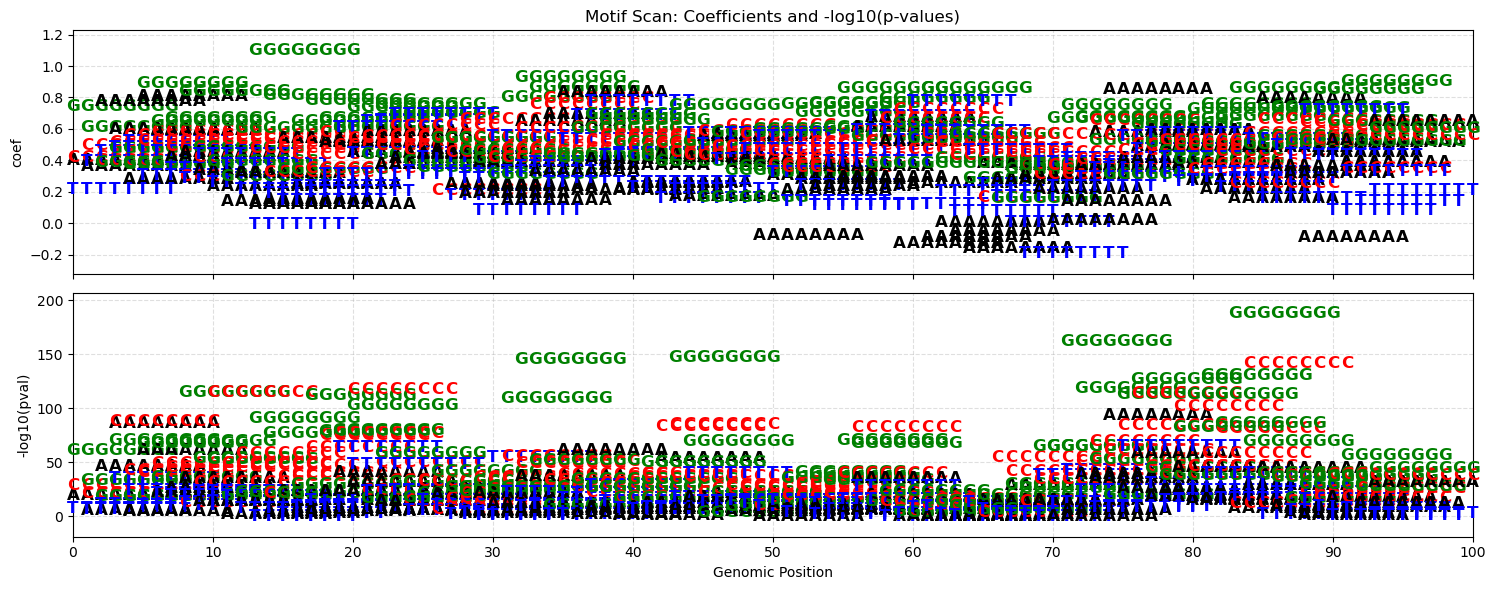

In [ ]:
def plot_aff_motif_effects(rows):
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    df = pd.DataFrame(rows, columns=[
        "wildcard_kmer", "filled_kmer", "window_index", "snp_index",
        "type", "allele", "coef", "pval"
    ])

    df = df[df["type"] == "AFF"].copy()
    df["coef"] = pd.to_numeric(df["coef"], errors="coerce")
    df["pval"] = pd.to_numeric(df["pval"], errors="coerce")
    df["-log10(pval)"] = -np.log10(df["pval"])
    df["absolute_position"] = df["window_index"] + df["snp_index"]

    region_length = df["absolute_position"].max() + 1

    allele_colors = {
        "A": "black",
        "C": "red",
        "G": "green",
        "T": "blue"
    }

    # Adaptive figure width based on region length
    fig_width = max(12, region_length * 0.15)
    fig, axs = plt.subplots(2, 1, figsize=(fig_width, 6), sharex=True)

    metrics = ["coef", "-log10(pval)"]

    for metric, ax in zip(metrics, axs):
        for _, row in df.iterrows():
            x = int(row["absolute_position"])
            y = row[metric]
            allele = row["allele"]
            color = allele_colors.get(allele, "gray")
            if pd.notna(y):
                ax.text(x, y, allele, color=color, fontsize=12, ha="center", va="center", fontweight="bold")

        # Dynamic y-limits with padding
        ymin = df[metric].min()
        ymax = df[metric].max()
        yrange = ymax - ymin if ymax != ymin else 1
        padding = yrange * 0.1
        ax.set_ylim(ymin - padding, ymax + padding)

        ax.set_ylabel(metric)
        ax.grid(True, linestyle="--", alpha=0.4)

    axs[1].set_xlabel("Genomic Position")
    axs[0].set_title("Motif Scan: Coefficients and -log10(p-values)")

    # Adjust x-tick spacing
    step = 10 if region_length > 80 else 5 if region_length > 40 else 1
    axs[1].set_xticks(range(0, region_length, step))

    plt.tight_layout()
    plt.show()
s
plot_aff_motif_effects(rows)